<a href="https://colab.research.google.com/github/nicolle-tq/Telecom-X-parte-2-/blob/main/Telecom-X-parte-2-.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Introducción**

En este proyecto se desarrolla un modelo de machine learning para predecir la cancelación de clientes (churn) en la empresa Telecom X.
Se utilizan datos tratados en el challenge anterior para entrenar modelos de clasificación que permitan identificar clientes con mayor riesgo de cancelación.


# **Importar librerías**

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# **Cargar archivo tratado**

In [59]:
df = pd.read_csv("datos_tratados.csv")

df.head()

,Cliente_ID,Churn,Genero,Adulto_Mayor,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_binario
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0.0
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0.0
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1.0
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1.0
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1.0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Cliente_ID                 7256 non-null   object 
 1   Churn                      7032 non-null   object 
 2   Genero                     7256 non-null   object 
 3   Adulto_Mayor               7256 non-null   object 
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   objec

# **Preparación de los datos**

In [61]:
# eliminar columnas si existen
df = df.drop(columns=["Cliente_ID", "Churn"], errors="ignore")

# convertir variables categóricas
df = pd.get_dummies(df, drop_first=True)

# separar variables
X = df.drop("Churn_binario", axis=1)
y = df["Churn_binario"]

# **Revisar proporción de cancelación**

In [62]:
y.value_counts()

,count
Churn_binario,
0.0,5163
1.0,1869


In [63]:
y.value_counts(normalize=True)

,proportion
Churn_binario,
0.0,0.734215
1.0,0.265785


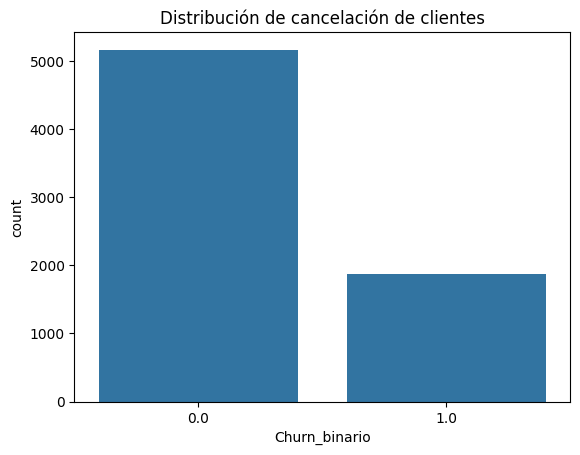

In [64]:
# Gráfico:
sns.countplot(x=y)
plt.title("Distribución de cancelación de clientes")
plt.show()

# **Análisis de correlación**

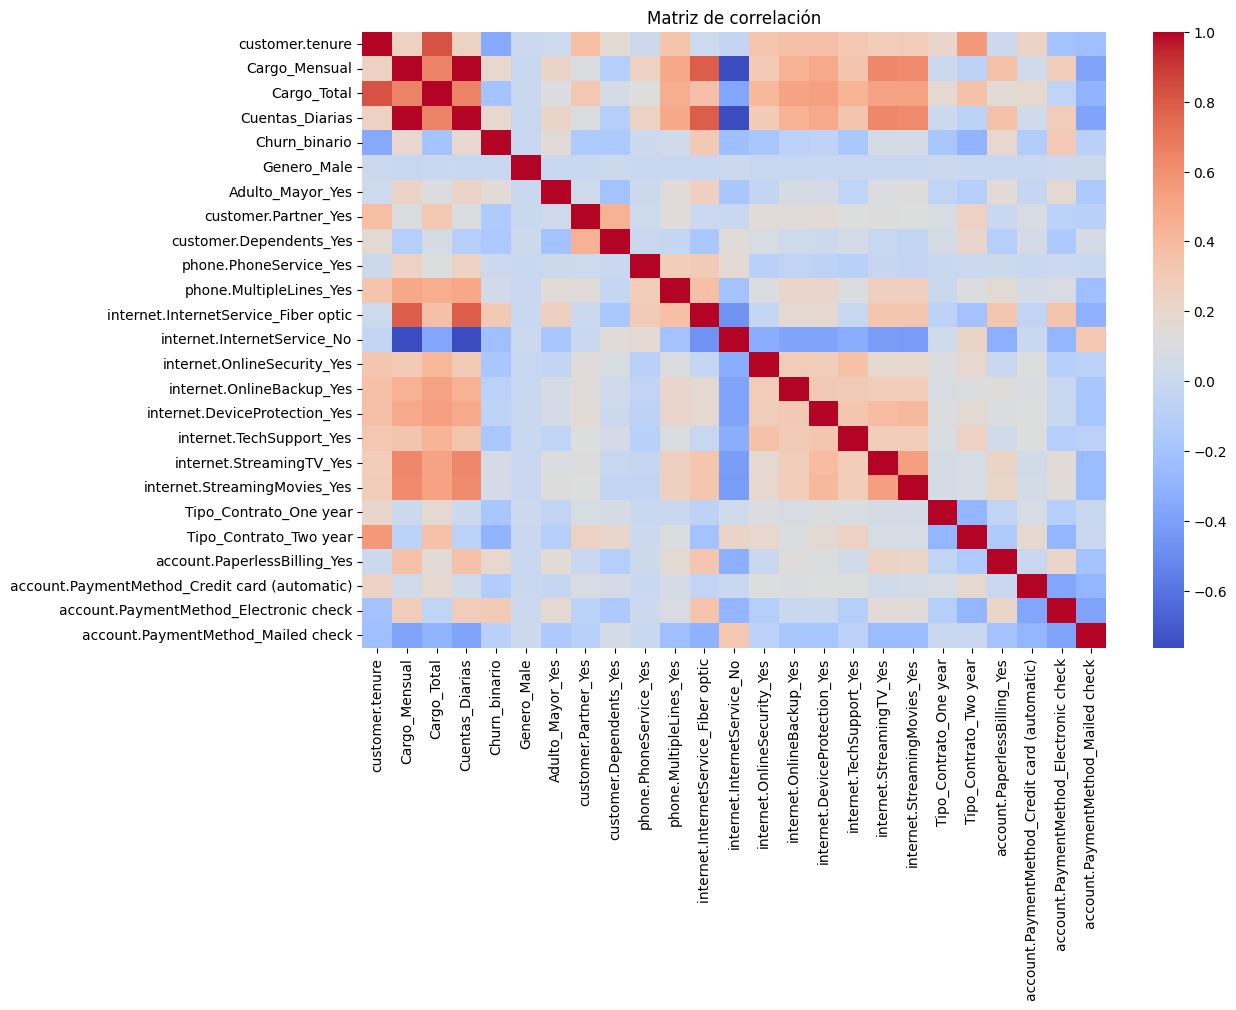

In [65]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

In [66]:
df.corr()["Churn_binario"].sort_values(ascending=False)

,Churn_binario
Churn_binario,1.000000
internet.InternetService_Fiber optic,0.307463
account.PaymentMethod_Electronic check,0.301455
Cuentas_Diarias,0.192858
Cargo_Mensual,0.192858
account.PaperlessBilling_Yes,0.191454
Adulto_Mayor_Yes,0.150541
internet.StreamingTV_Yes,0.063254
internet.StreamingMovies_Yes,0.060860
phone.MultipleLines_Yes,0.040033


# **Separar entrenamiento y prueba**

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# **Normalización (para regresión logística)**

In [68]:
# eliminar filas con valores nulos
df = df.dropna()

In [69]:
X = df.drop("Churn_binario", axis=1)
y = df["Churn_binario"]

In [70]:
# separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Modelo 1 — Regresión Logística**

In [72]:
y.isna().sum()

np.int64(0)

In [73]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

pred_lr = modelo_lr.predict(X_test_scaled)